In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [127]:
df = pd.read_csv('dev.csv')

In [128]:
df.describe()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,6.830000e+02,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,1.076720e+06,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,6.206440e+05,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,6.337500e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.776170e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171795e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238705e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [129]:
df.columns

Index(['Sample code number', 'Clump Thickness', 'Uniformity of Cell Size',
       'Uniformity of Cell Shape', 'Marginal Adhesion',
       'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
       'Normal Nucleoli', 'Mitoses', 'Class'],
      dtype='str')

In [130]:
df.shape

(683, 11)

In [131]:
df.isnull().sum()

Sample code number             0
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

<Axes: >

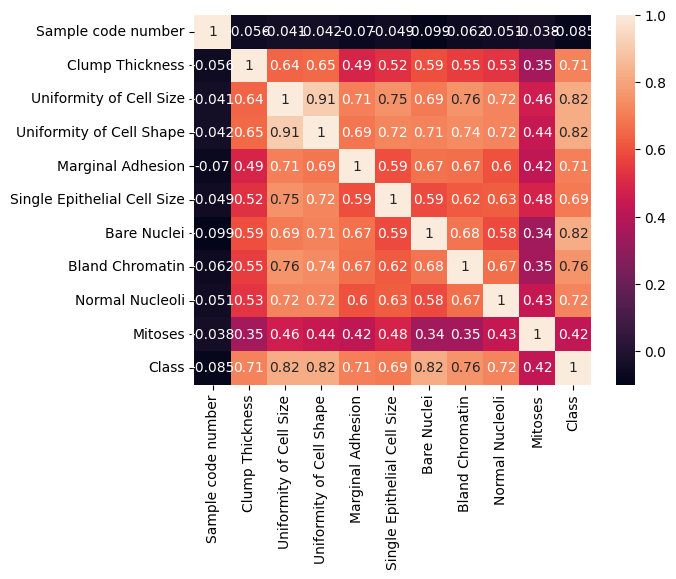

In [132]:
sns.heatmap(df.corr(), annot=True)

<Axes: xlabel='Mitoses', ylabel='Class'>

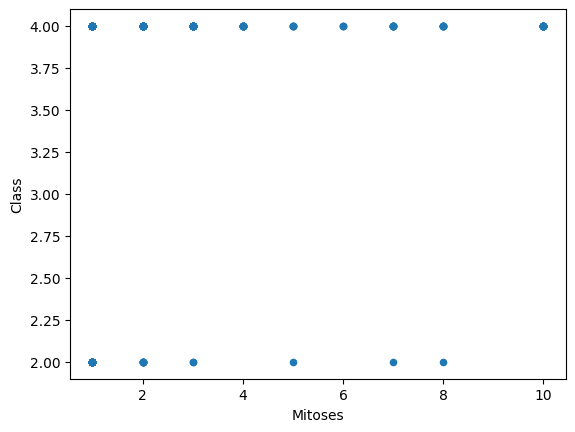

In [133]:
df.plot.scatter(x='Mitoses', y='Class')

array([[<Axes: title={'center': 'Sample code number'}>,
        <Axes: title={'center': 'Clump Thickness'}>,
        <Axes: title={'center': 'Uniformity of Cell Size'}>],
       [<Axes: title={'center': 'Uniformity of Cell Shape'}>,
        <Axes: title={'center': 'Marginal Adhesion'}>,
        <Axes: title={'center': 'Single Epithelial Cell Size'}>],
       [<Axes: title={'center': 'Bare Nuclei'}>,
        <Axes: title={'center': 'Bland Chromatin'}>,
        <Axes: title={'center': 'Normal Nucleoli'}>],
       [<Axes: title={'center': 'Mitoses'}>,
        <Axes: title={'center': 'Class'}>, <Axes: >]], dtype=object)

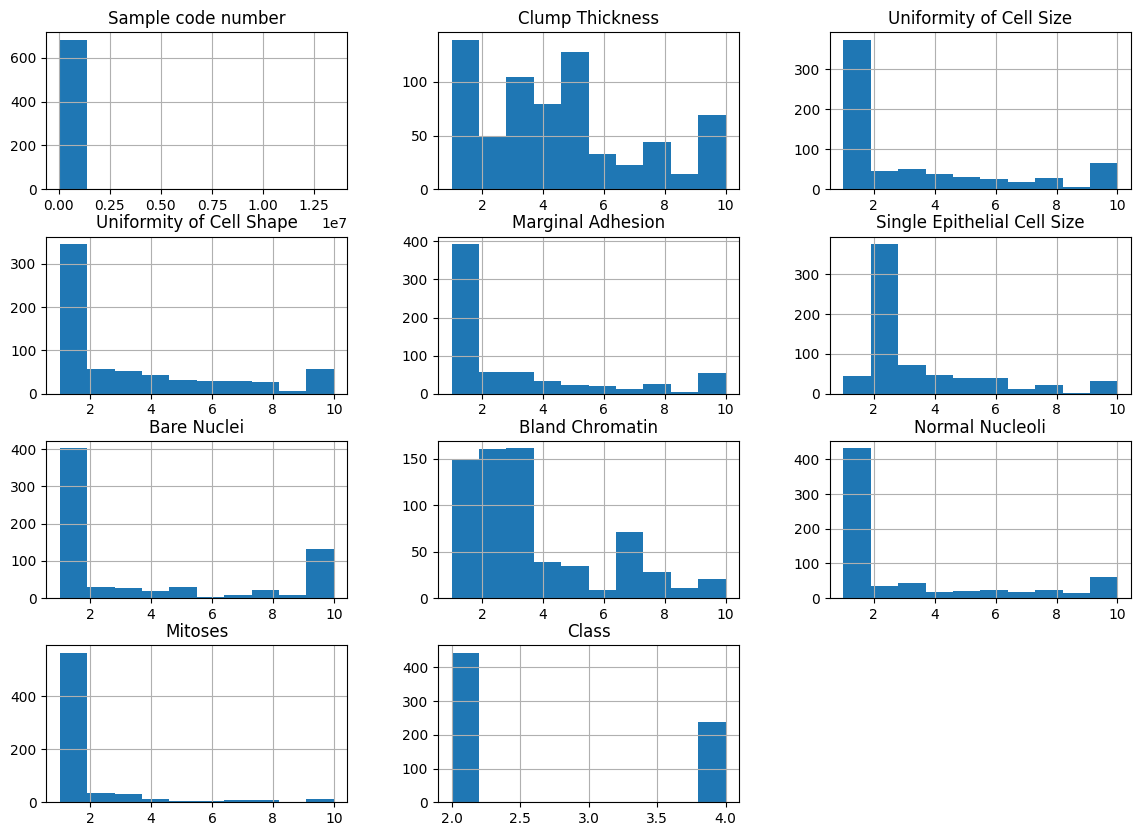

In [134]:
df.hist(figsize=(14, 10))

In [135]:
df['Class'] = df['Class'].map({4: 0, 2: 1})

In [136]:
df['Class']

0      1
1      1
2      1
3      1
4      1
      ..
678    1
679    1
680    0
681    0
682    0
Name: Class, Length: 683, dtype: int64

In [137]:
df

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,1
1,1002945,5,4,4,5,7,10,3,2,1,1
2,1015425,3,1,1,1,2,2,3,1,1,1
3,1016277,6,8,8,1,3,4,3,7,1,1
4,1017023,4,1,1,3,2,1,3,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
678,776715,3,1,1,1,3,2,1,1,1,1
679,841769,2,1,1,1,2,1,1,1,1,1
680,888820,5,10,10,3,7,3,8,10,2,0
681,897471,4,8,6,4,3,4,10,6,1,0


In [138]:
x = df.drop(['Sample code number', 'Uniformity of Cell Shape', 'Mitoses', 'Class'], axis=1).values
y = df['Class'].values
print(x)
print(y)

[[ 5  1  1 ...  1  3  1]
 [ 5  4  5 ... 10  3  2]
 [ 3  1  1 ...  2  3  1]
 ...
 [ 5 10  3 ...  3  8 10]
 [ 4  8  4 ...  4 10  6]
 [ 4  8  5 ...  5 10  4]]
[1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 0 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 1
 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0
 0 1 1 1 0 1 1 1 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 0
 0 1 1 0 1 1 0 0 1 1 1 1 0 0 1 1 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 1 0 0 0 1 0
 0 1 1 1 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 1 0 0 0 1 1 0 1 1 0 0 0 0 1 0 0
 1 0 0 0 1 0 1 0 0 0 0 1 1 1 1 1 1 0 0 1 1 0 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0
 0 0 1 0 1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 0 1 0 1 0 0 1 1
 0 1 1 1 0 1 1 0 0 1 1 0 1 0 1 1 0 1 0 0 0 1 1 0 0 1 0 1 1 0 0 1 1 1 0 1 1
 1 0 0 1 1 1 0 1 1 0 0 0 0 0 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1 0
 1 1 1 0 1 0 1 1 1 

In [139]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=24, stratify=y)

In [140]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [141]:
# Instantiate & train
lr = LogisticRegression(random_state=24)
lr.fit(x_train_sc, y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",24
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [142]:
# Predict
y_pred_lr = lr.predict(x_test_sc)
y_prob_lr = lr.predict_proba(x_test_sc)   # class probabilities
 


<Axes: >

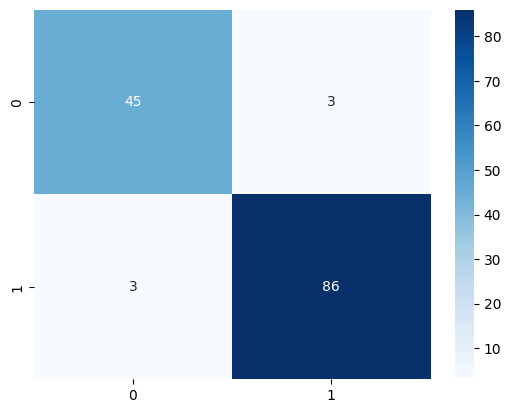

In [143]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')


In [144]:
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", lr.score(x_test_sc, y_test))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        48
           1       0.97      0.97      0.97        89

    accuracy                           0.96       137
   macro avg       0.95      0.95      0.95       137
weighted avg       0.96      0.96      0.96       137

Accuracy: 0.9562043795620438


From my dataset, there are are no missing values.
There are 11 columns and 683 rows in my dataset.
I have decided to drop the following columns: 
i) Sample code number because its always takens at random.
ii) Uniformity of Cell Shape has a high correlation with Uniformity of Cell Size and can be replaced easily by Uniformity of Cell Size with a higher variance
iii) Mitoses will also be dropped because of its lower correlation with Class and a low variance.
